# Error Analysis & Visualizations — RAG-Driven Data Cleaning

This notebook builds the master predictions CSV, runs full error analysis, and generates all visualization figures for the report and presentation.

**Figures generated:**
1. Overall accuracy bar chart (standard + CE eval + UNKNOWN rate)
2. Per-attribute standard accuracy heatmap
3. Per-attribute CE eval heatmap
4. Outcome stacked bar chart (correct / correct CE / wrong / UNKNOWN)
5. Numeric vs text attributes grouped bar
6. Improvement per attribute — LLM-only → best config
7. Standard vs CE eval comparison (semantic gap)
8. Retrieval quality — Recall, Precision, NDCG across embedding models
9. UNKNOWN rate comparison
10. Per-config per-attribute radar chart
11. Persistent failure analysis table
12. Prediction correctness heatmap (task × config)

## 1. Setup

In [2]:
import sys
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib64/python3.12/site-packages')
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib/python3.12/site-packages')

import os, glob, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from sentence_transformers import CrossEncoder
warnings.filterwarnings('ignore')


# ── Paths ─────────────────────────────────────────────────────────────────────
RESULTS_DIR  = 'results_ohne_UNKNOWN'
FIGURES_DIR  = 'figures_final_ohne_UNKNOWN'
HF_CACHE     = '/home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub'
os.makedirs(FIGURES_DIR, exist_ok=True)

NUMERIC_ATTRIBUTES = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}

FILES = {
    'llm_prediction':                 f'{RESULTS_DIR}/exp1_llm_only.csv',
    'rag_minilm_prediction':          f'{RESULTS_DIR}/exp2_rag_minilm.csv',
    'rag_minilm_reranker_prediction': f'{RESULTS_DIR}/exp3_rag_minilm_reranker.csv',
    'rag_bge_reranker_prediction':    f'{RESULTS_DIR}/exp4_rag_bge_reranker.csv',
    'rag_te_reranker_prediction':     f'{RESULTS_DIR}/exp5_rag_openai_reranker.csv',
}

CONFIG_LABELS = {
    'llm_prediction':                 'LLM-only',
    'rag_minilm_prediction':          'RAG-MiniLM',
    'rag_minilm_reranker_prediction': 'MiniLM+RR',
    'rag_bge_reranker_prediction':    'BGE+RR',
    'rag_te_reranker_prediction':     'TE+RR',
}

# ── Style ─────────────────────────────────────────────────────────────────────
COLORS = ['#A7D3F2', '#7FB3D5', '#3C8DBC', "#2F739B", '#1D5F8A', '#0B3C5D']
GREY   = "#B0B0B0"
plt.rcParams.update({
    'font.family':  'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi': 120
})

MASTER_FILE         = f'{RESULTS_DIR}/master_predictions.csv'
ERROR_ANALYSIS_FILE = f'{RESULTS_DIR}/error_analysis.csv'

# Load CrossEncoder
CE_SNAP = glob.glob(f'{HF_CACHE}/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/*/')
CE_PATH = CE_SNAP[0].rstrip('/') if CE_SNAP else 'cross-encoder/ms-marco-MiniLM-L-6-v2'
cross_encoder = CrossEncoder(CE_PATH)
print(f'CrossEncoder: {CE_PATH}')
print(f'Figures will be saved to: {FIGURES_DIR}/')

CrossEncoder: /home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/c5ee24cb16019beea0893ab7796b1df96625c6b8
Figures will be saved to: figures_final_ohne_UNKNOWN/


## 2. Evaluation Functions

In [3]:
def fix_prediction(pred):
    if isinstance(pred, str) and pred.strip().upper().startswith('VALUE:'):
        val = pred.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if val.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else val
    return pred

def is_correct_standard(predicted, ground_truth, attribute):
    if not predicted or str(predicted).strip().lower() in {'','nan','none','unknown','null'}:
        return False
    if attribute in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(predicted).replace(',','').strip())
            g = float(str(ground_truth).replace(',','').strip())
            return p == g  # exact match — source variation is 0% confirmed
        except: pass
    p, g = str(predicted).lower().strip(), str(ground_truth).lower().strip()
    return p == g or p in g or g in p

def evaluate_ce(predicted, ground_truth, attribute):
    if predicted == 'UNKNOWN' or str(predicted).lower() in {'nan','none','null',''}:
        return 'wrong'
    if attribute in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(predicted).replace(',','').strip())
            g = float(str(ground_truth).replace(',','').strip())
            if g == 0: return 'correct' if p == 0 else 'wrong'
            r = abs(p-g)/abs(g)
            return 'correct' if r == 0.0 else ('acceptable' if r <= 0.10 else 'wrong')
            # exact = correct | within 10% = acceptable | beyond = wrong
        except: return 'wrong'
    score = cross_encoder.predict([[ground_truth, predicted]])[0]
    return 'correct' if score > 2.0 else ('acceptable' if score > -1.0 else 'wrong')

def outcome(predicted, ground_truth, attribute):
    if str(predicted) == 'UNKNOWN' or str(predicted).lower() in {'nan','none','null',''}:
        return 'UNKNOWN'
    if is_correct_standard(predicted, ground_truth, attribute):
        return 'correct'
    if evaluate_ce(predicted, ground_truth, attribute) in {'correct','acceptable'}:
        return 'correct (CE)'
    return 'wrong value'

print('Evaluation functions ready.')

Evaluation functions ready.


## 3. Build Master Predictions CSV

In [4]:
master = None
for col_name, filepath in FILES.items():
    if not os.path.exists(filepath):
        print(f'  ⚠️  Not found: {filepath} — skipping'); continue
    df = pd.read_csv(filepath)
    df['predicted'] = df['predicted'].apply(fix_prediction)
    if master is None:
        master = df[['df1_idx','attribute','is_numeric','ground_truth']].copy()
        master = master.sort_values(['df1_idx','attribute']).reset_index(drop=True)
    pred = df[['df1_idx','attribute','predicted']].rename(columns={'predicted': col_name})
    master = master.merge(pred, on=['df1_idx','attribute'], how='left')
    print(f'  ✓ {col_name}')

master['manual_prediction'] = ''
master.to_csv(MASTER_FILE, index=False)

available = [c for c in FILES.keys() if c in master.columns]
short_labels = [CONFIG_LABELS[c] for c in available]

# Pre-compute outcomes
for col in available:
    master[f'{col}_outcome'] = master.apply(
        lambda r: outcome(r[col], r['ground_truth'], r['attribute']), axis=1)
    master[f'{col}_std'] = master.apply(
        lambda r: is_correct_standard(r[col], r['ground_truth'], r['attribute']), axis=1)
    master[f'{col}_ce'] = master.apply(
        lambda r: evaluate_ce(r[col], r['ground_truth'], r['attribute']), axis=1)

print(f'\n✓ Master CSV: {len(master)} tasks × {master.shape[1]} columns')
master[['df1_idx','attribute','ground_truth'] + available].head(10)

  ✓ llm_prediction
  ✓ rag_minilm_prediction
  ✓ rag_minilm_reranker_prediction
  ✓ rag_bge_reranker_prediction
  ✓ rag_te_reranker_prediction

✓ Master CSV: 96 tasks × 25 columns


,df1_idx,attribute,ground_truth,llm_prediction,rag_minilm_prediction,rag_minilm_reranker_prediction,rag_bge_reranker_prediction,rag_te_reranker_prediction
0,0,model_number,GV-N3080GAMING OC-10GD,NVIDIA GeForce RTX 3080 Gaming OC,GV-N3080GAMING OC-10GD,GV-N3080EAGLE-OC-10GD,GV-N3080GAMING OC-10GD,GV-N3080GAMING OC-10GD
1,2,model_number,CSSD-F960GBMP510,CSSD-F960GBMP510,CSSD-F960GBMP510,CSSD-F960GBMP510,CSSD-F960GBMP510,CSSD-F960GBMP510
2,2,read_speed_mb_s,3480.0,UNKNOWN,3480,3480.0,3480.0,3480.0
3,2,write_speed_mb_s,3000.0,3480,3000,3000.0,3000,3000
4,3,read_speed_mb_s,226.0,UNKNOWN,250,226,226,226
5,4,width_mm,433.0,UNKNOWN,433,433,433,433
6,5,bus_type,PCIe 3.0 x16,PCIe,PCIe 3.0,PCIe 3.0 x16,PCIe 3.0 x16,PCIe 3.0 x16
7,5,model_number,90YV0CV2-M0NA00,RTX-2060-S-8G,GV-N165D5-4GD,90YV0CV2-M0NA00,90YV0CV2-M0NA00,90YV0CV2-M0NA00
8,6,bus_type,USB 3.0,USB 3.0,USB 3.0 (assuming it's a standard USB 3.0 flas...,USB 2.0,USB 3.0,USB 3.1
9,8,model_number,GV-N166SOC-6GD,GV-N166SUPER-6GD,GV-N166SOC-6GD,GV-N166SOC-6GD,UNKNOWN,GV-N166SOC-6GD


## 4. Compute Summary Statistics

In [5]:
summary = []
for col in available:
    rows = master.dropna(subset=[col])
    summary.append({
        'config':   CONFIG_LABELS[col],
        'col':      col,
        'std':      rows[f'{col}_std'].mean() * 100,
        'ce':       rows[f'{col}_ce'].isin(['correct','acceptable']).mean() * 100,
        'unknown':  (rows[col] == 'UNKNOWN').mean() * 100,
        'n':        len(rows)
    })
sum_df = pd.DataFrame(summary)
print(sum_df[['config','std','ce','unknown','n']].round(1).to_string(index=False))

    config  std   ce  unknown  n
  LLM-only 13.5 25.0     35.4 96
RAG-MiniLM 37.5 51.0      6.2 96
 MiniLM+RR 66.7 77.1      6.2 96
    BGE+RR 69.8 79.2      2.1 96
     TE+RR 70.8 81.2      2.1 96


## Figure 1 — Overall Accuracy: Standard + CE Eval + UNKNOWN Rate

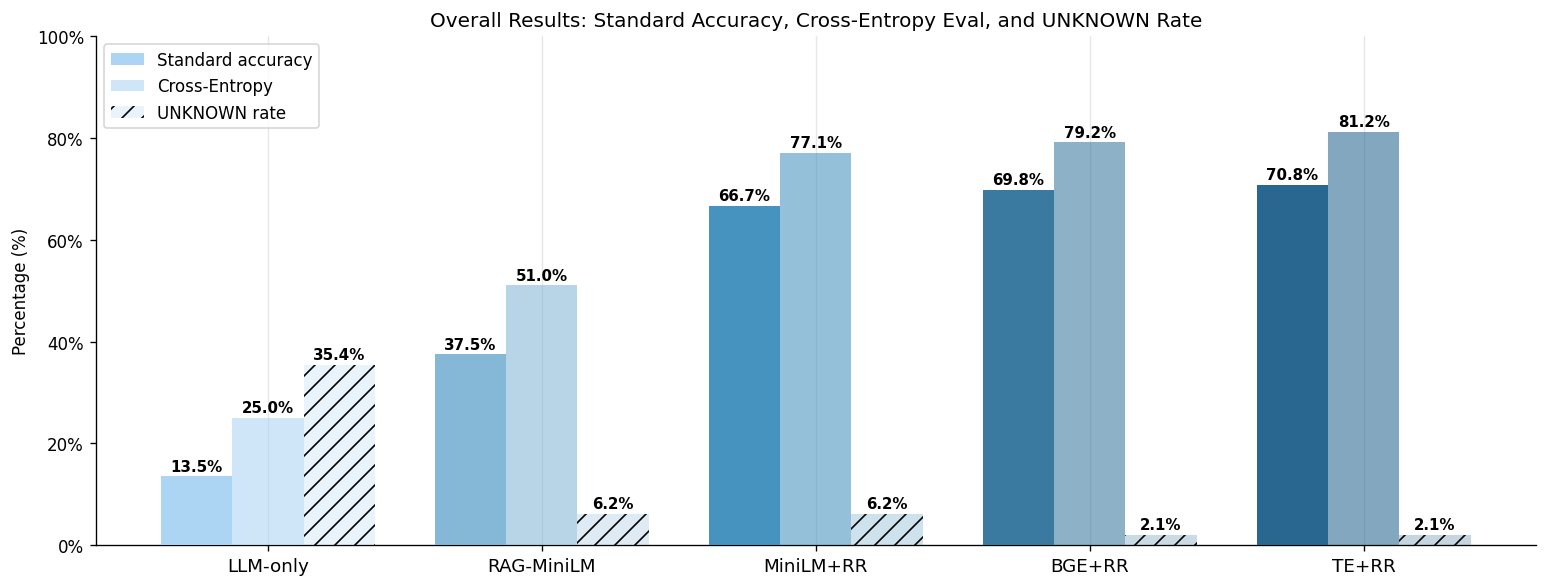

✓ fig1_overall_accuracy.png


In [ ]:
x = np.arange(len(sum_df)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 5))

b1 = ax.bar(x-w,   sum_df['std'],     w, color=COLORS[:len(sum_df)], alpha=0.95, label='Standard accuracy', zorder=3)
b2 = ax.bar(x,     sum_df['ce'],      w, color=COLORS[:len(sum_df)], alpha=0.55, label='Cross-Entropy', zorder=3)
b3 = ax.bar(x+w,   sum_df['unknown'], w, color=COLORS[:len(sum_df)], alpha=0.25, hatch='//', label='UNKNOWN rate', zorder=3)

for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in b3:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(sum_df['config'], fontsize=11)
ax.set_ylabel('Percentage (%)'); ax.set_ylim(0, 100)
ax.set_title('Overall Results: Standard Accuracy, Cross-Entropy Eval, and UNKNOWN Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3, zorder=0); ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig1_overall_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig1_overall_accuracy.png')

## Figure 2 — Per-Attribute Standard Accuracy Heatmap

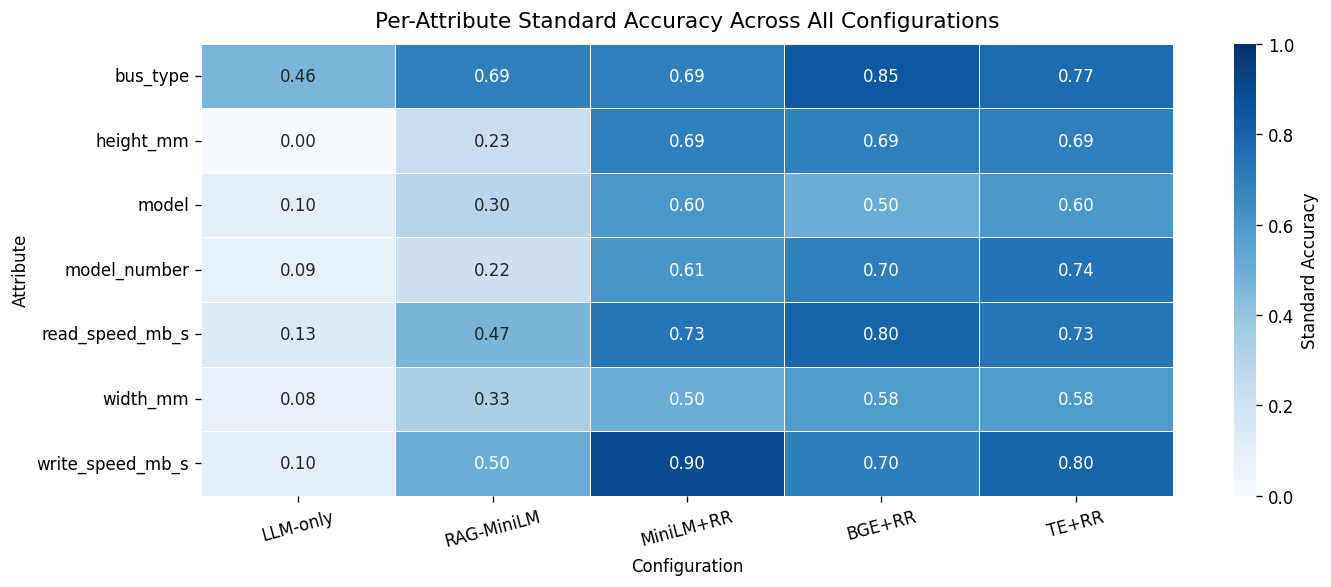

✓ fig2_heatmap_standard.png


In [7]:
attrs = sorted(master['attribute'].unique())
heatmap_data = pd.DataFrame(index=attrs, columns=short_labels)
for col, label in zip(available, short_labels):
    for attr in attrs:
        sub = master[master['attribute'] == attr]
        heatmap_data.loc[attr, label] = round(sub[f'{col}_std'].mean(), 3)
heatmap_data = heatmap_data.astype(float)

fig, ax = plt.subplots(figsize=(len(available)*2+2, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'label': 'Standard Accuracy'})
ax.set_title('Per-Attribute Standard Accuracy Across All Configurations', fontsize=13, pad=10)
ax.set_xlabel('Configuration'); ax.set_ylabel('Attribute')
ax.tick_params(axis='x', rotation=15); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig2_heatmap_standard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig2_heatmap_standard.png')

## Figure 3 — Per-Attribute CE Eval Heatmap

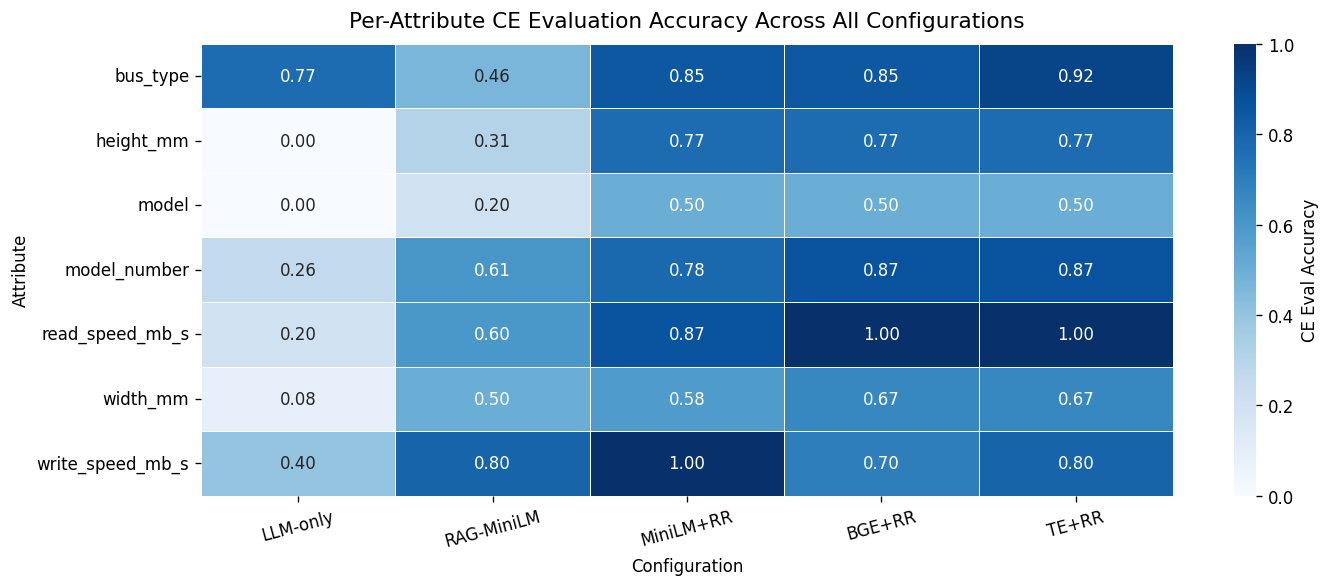

✓ fig3_heatmap_ce.png


In [8]:
heatmap_ce = pd.DataFrame(index=attrs, columns=short_labels)
for col, label in zip(available, short_labels):
    for attr in attrs:
        sub = master[master['attribute'] == attr]
        heatmap_ce.loc[attr, label] = round(
            sub[f'{col}_ce'].isin(['correct','acceptable']).mean(), 3)
heatmap_ce = heatmap_ce.astype(float)

fig, ax = plt.subplots(figsize=(len(available)*2+2, 5))
sns.heatmap(heatmap_ce, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax, cbar_kws={'label': 'CE Eval Accuracy'})
ax.set_title('Per-Attribute CE Evaluation Accuracy Across All Configurations', fontsize=13, pad=10)
ax.set_xlabel('Configuration'); ax.set_ylabel('Attribute')
ax.tick_params(axis='x', rotation=15); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig3_heatmap_ce.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig3_heatmap_ce.png')

## Figure 4 — Outcome Stacked Bar (correct / correct CE / wrong / UNKNOWN)

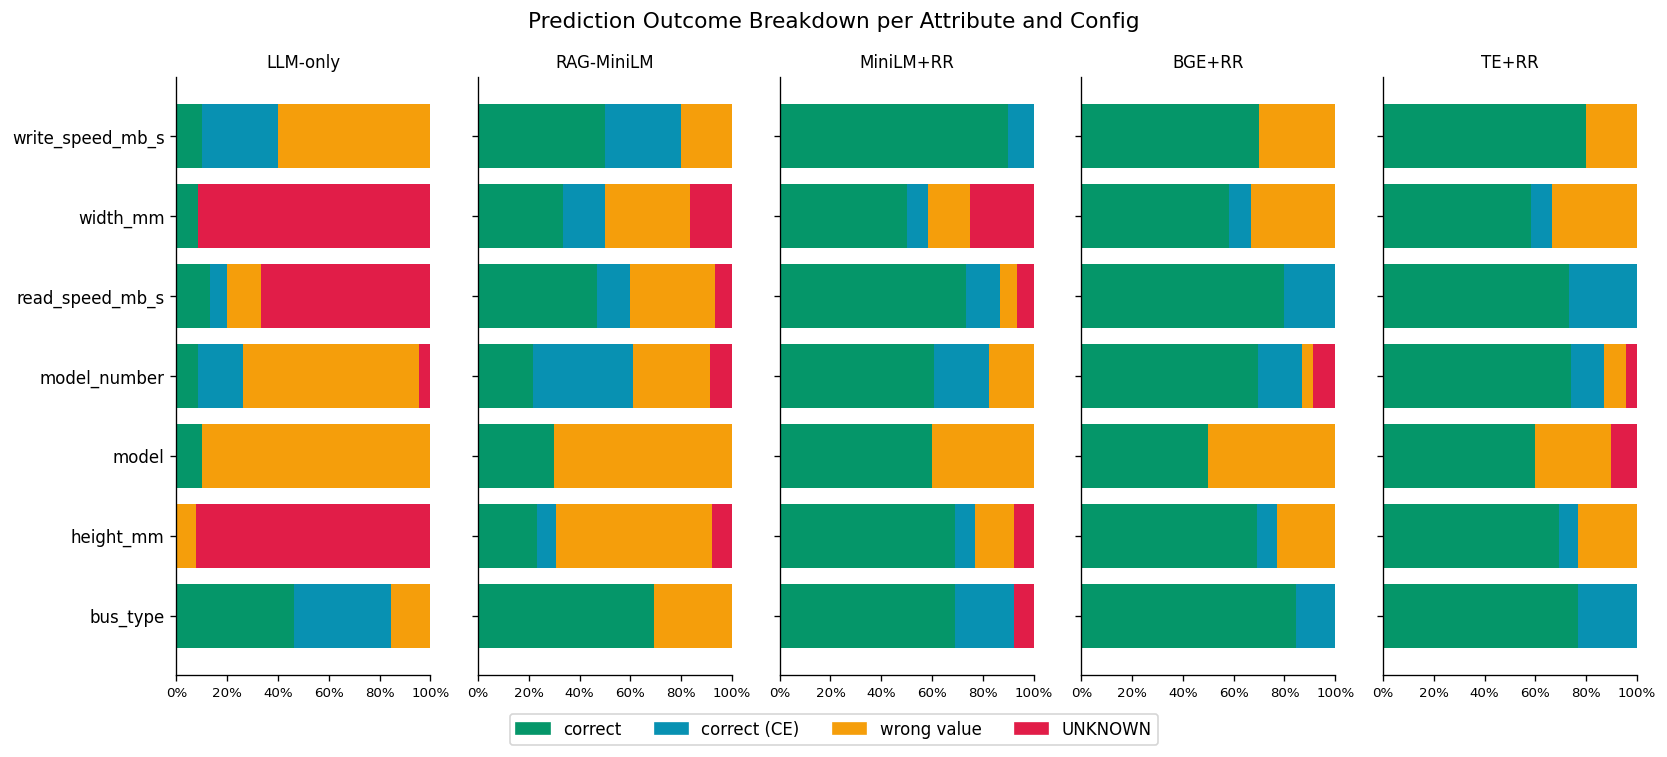

✓ fig4_outcome_stacked.png


In [9]:
outcome_colors = {'correct':'#059669','correct (CE)':'#0891B2','wrong value':'#F59E0B','UNKNOWN':'#E11D48'}
cats = ['correct','correct (CE)','wrong value','UNKNOWN']

fig, axes = plt.subplots(1, len(available), figsize=(len(available)*2.8, 6), sharey=True)
if len(available) == 1: axes = [axes]

for ax, col, label in zip(axes, available, short_labels):
    data = {}
    for attr in attrs:
        sub = master[master['attribute'] == attr]
        counts = sub[f'{col}_outcome'].value_counts()
        total  = len(sub)
        data[attr] = {c: counts.get(c, 0)/total for c in cats}
    df_plot = pd.DataFrame(data).T
    bottom = np.zeros(len(attrs))
    for cat in cats:
        vals = df_plot[cat].values if cat in df_plot else np.zeros(len(attrs))
        ax.barh(attrs, vals, left=bottom, color=outcome_colors[cat], label=cat)
        bottom += vals
    ax.set_title(label, fontsize=10)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.tick_params(axis='x', labelsize=8)

handles = [mpatches.Patch(color=outcome_colors[c], label=c) for c in cats]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5,-0.05), fontsize=10)
fig.suptitle('Prediction Outcome Breakdown per Attribute and Config', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig4_outcome_stacked.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig4_outcome_stacked.png')

## Figure 5 — Numeric vs Text Attributes

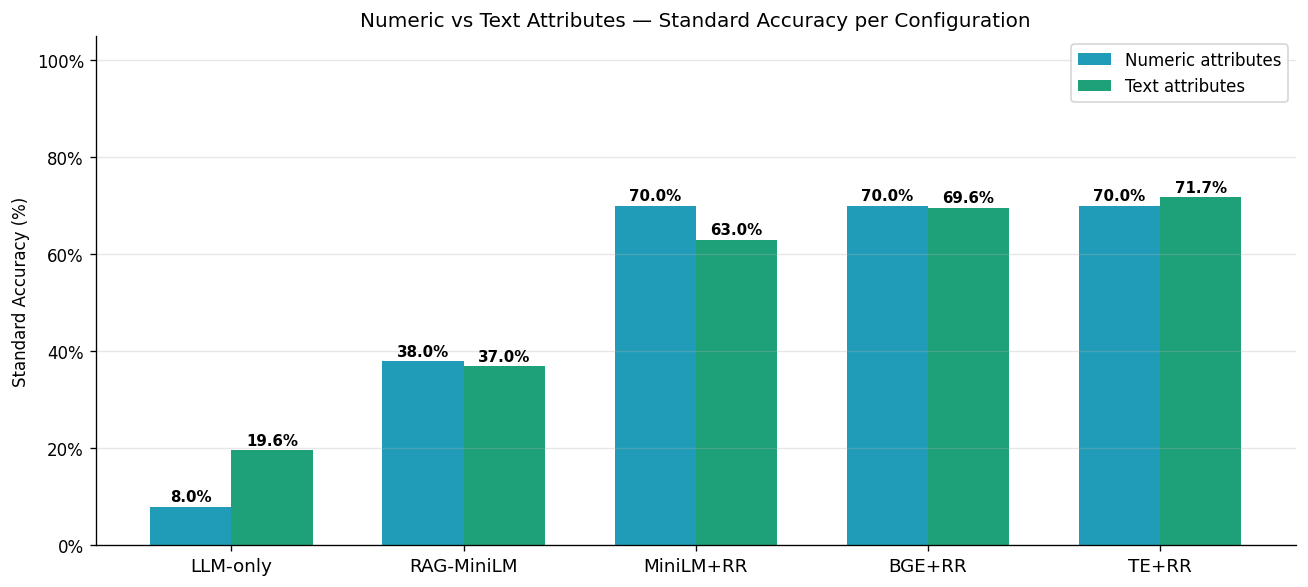

✓ fig5_numeric_vs_text.png


In [10]:
num_attrs  = [a for a in attrs if a in NUMERIC_ATTRIBUTES]
text_attrs = [a for a in attrs if a not in NUMERIC_ATTRIBUTES]

results = []
for col, label in zip(available, short_labels):
    num_acc  = master[master['attribute'].isin(num_attrs)][f'{col}_std'].mean() * 100
    text_acc = master[master['attribute'].isin(text_attrs)][f'{col}_std'].mean() * 100
    results.append({'config': label, 'Numeric attributes': num_acc, 'Text attributes': text_acc})
res_df = pd.DataFrame(results)

x = np.arange(len(res_df)); w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x-w/2, res_df['Numeric attributes'], w, color='#0891B2', alpha=0.9, label='Numeric attributes')
b2 = ax.bar(x+w/2, res_df['Text attributes'],    w, color='#059669', alpha=0.9, label='Text attributes')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(res_df['config'], fontsize=11)
ax.set_ylabel('Standard Accuracy (%)'); ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Numeric vs Text Attributes — Standard Accuracy per Configuration')
ax.grid(axis='y', alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig5_numeric_vs_text.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig5_numeric_vs_text.png')

## Figure 6 — Improvement per Attribute: LLM-only → Best Config

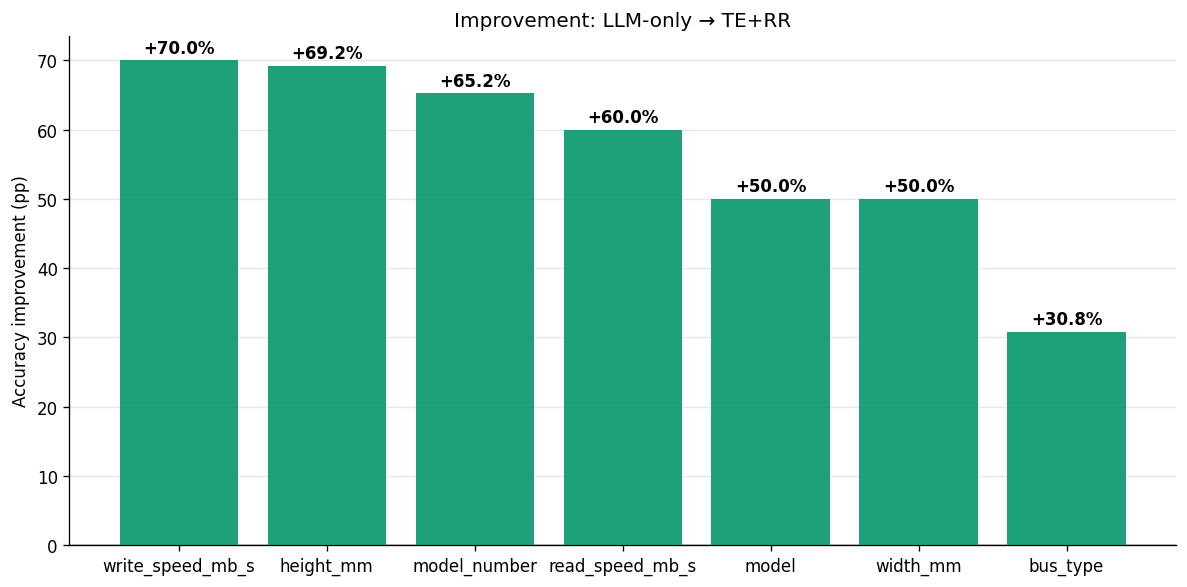

✓ fig6_improvement.png


In [11]:
llm_col  = available[0]  # LLM-only
best_col = available[-1] # last config (assumed best — change if needed)

impr = []
for attr in attrs:
    sub  = master[master['attribute'] == attr]
    llm  = sub[f'{llm_col}_std'].mean() * 100
    best = sub[f'{best_col}_std'].mean() * 100
    impr.append({'attribute': attr, 'llm': llm, 'best': best, 'delta': best - llm})
impr_df = pd.DataFrame(impr).sort_values('delta', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#059669' if d >= 0 else '#E11D48' for d in impr_df['delta']]
bars = ax.bar(impr_df['attribute'], impr_df['delta'], color=bar_colors, alpha=0.9, zorder=3)
for bar, val in zip(bars, impr_df['delta']):
    ypos = bar.get_height()+0.5 if val >= 0 else bar.get_height()-2
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f'+{val:.1f}%' if val >= 0 else f'{val:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Accuracy improvement (pp)')
ax.set_title(f'Improvement: LLM-only → {CONFIG_LABELS[best_col]}')
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig6_improvement.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig6_improvement.png')

## Figure 7 — Standard vs CE Eval Gap (Semantic Evaluation)

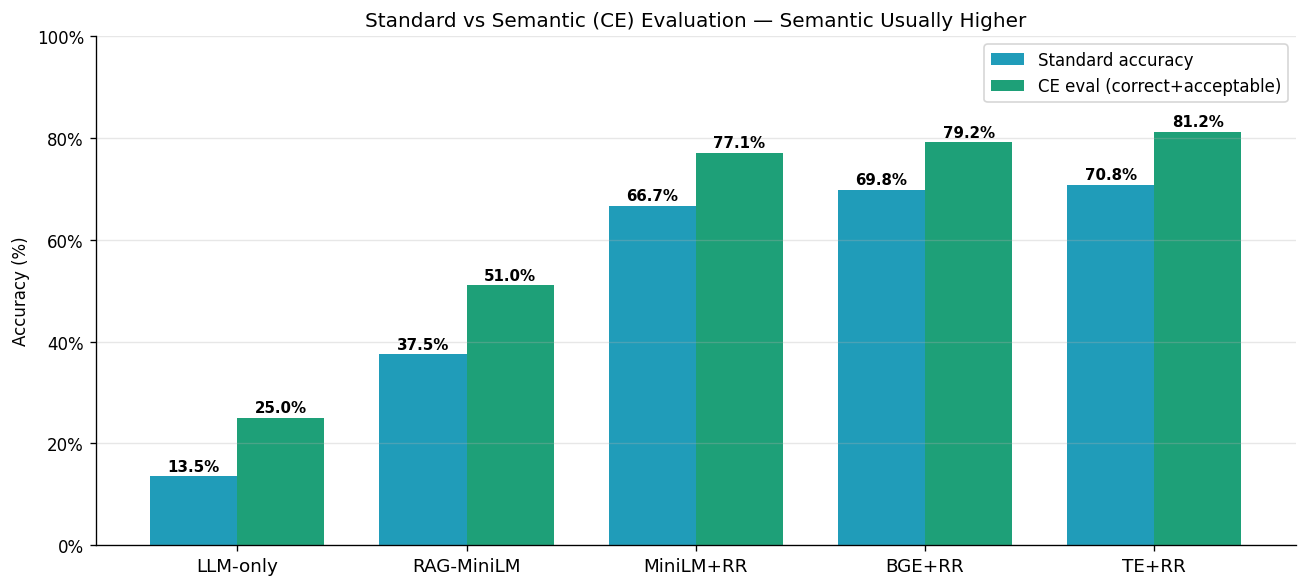

✓ fig7_std_vs_ce.png


In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(sum_df)); w = 0.38
b1 = ax.bar(x-w/2, sum_df['std'], w, color='#0891B2', alpha=0.9, label='Standard accuracy')
b2 = ax.bar(x+w/2, sum_df['ce'],  w, color='#059669', alpha=0.9, label='CE eval (correct+acceptable)')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(sum_df['config'], fontsize=11)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Standard vs Semantic (CE) Evaluation — Semantic Usually Higher')
ax.grid(axis='y', alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig7_std_vs_ce.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig7_std_vs_ce.png')

## Figure 8 — UNKNOWN Rate Comparison

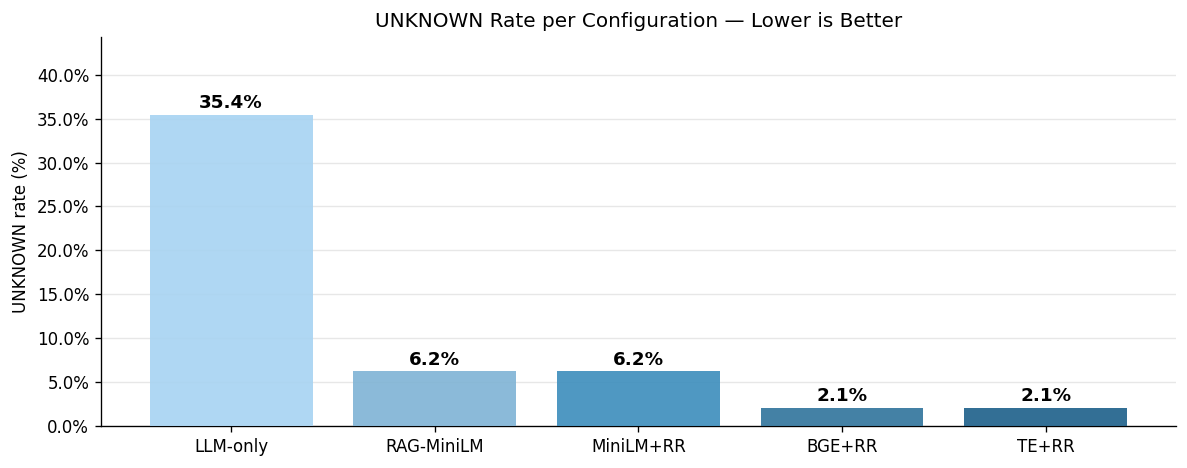

✓ fig8_unknown_rate.png


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(sum_df['config'], sum_df['unknown'],
              color=COLORS[:len(sum_df)], alpha=0.9, zorder=3)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('UNKNOWN rate (%)')
ax.set_title('UNKNOWN Rate per Configuration — Lower is Better')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, max(sum_df['unknown'])*1.25)
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig8_unknown_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig8_unknown_rate.png')

## Figure 9 — Per-Config Per-Attribute Bar Grid

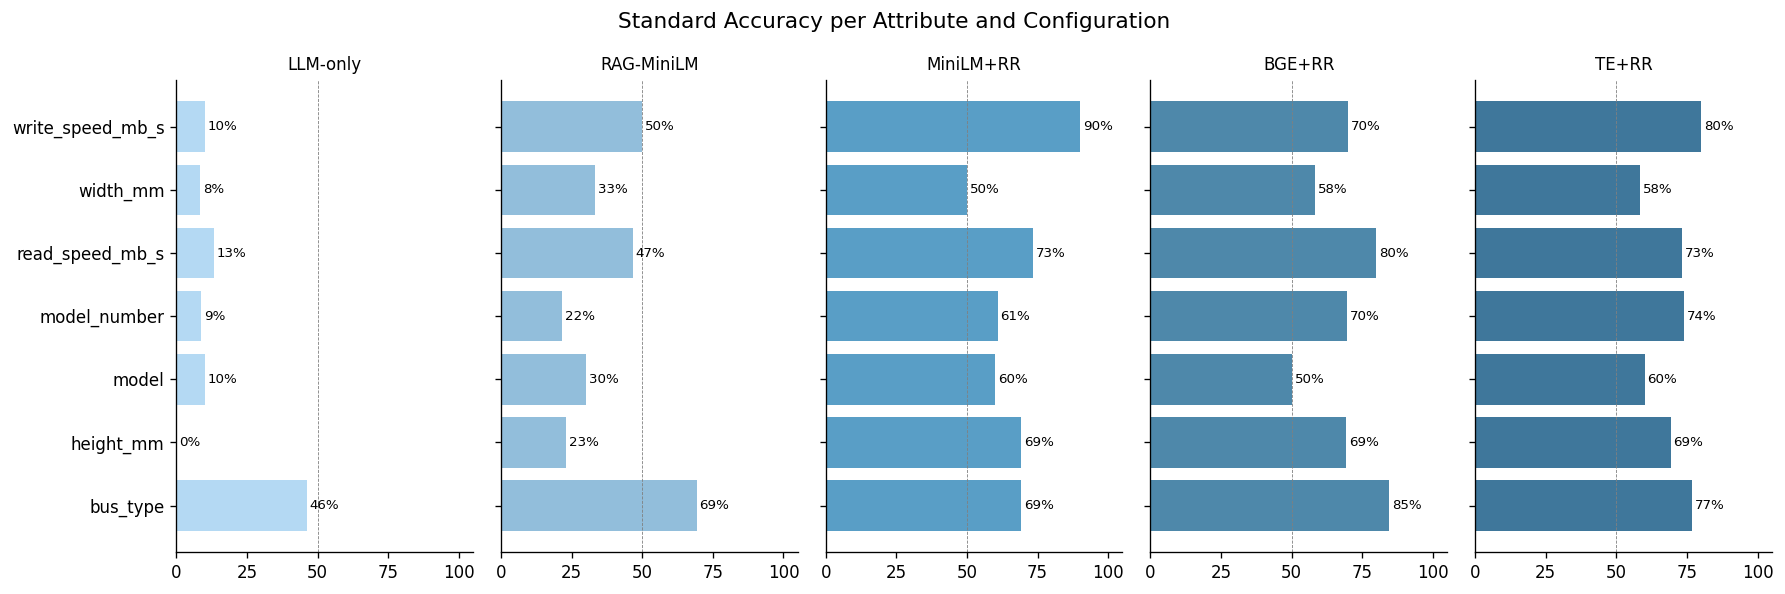

✓ fig9_per_config_bars.png


In [14]:
n_cols = len(available)
fig, axes = plt.subplots(1, n_cols, figsize=(n_cols*3, 5), sharey=True)
if n_cols == 1: axes = [axes]

for ax, col, label, color in zip(axes, available, short_labels, COLORS):
    vals = [master[master['attribute']==a][f'{col}_std'].mean()*100 for a in attrs]
    bar_colors = ['#E11D48' if v == 0 else color for v in vals]
    bars = ax.barh(attrs, vals, color=bar_colors, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(min(val+1, 98), bar.get_y()+bar.get_height()/2,
                f'{val:.0f}%', va='center', fontsize=8)
    ax.set_xlim(0, 105)
    ax.set_title(label, fontsize=10)
    ax.axvline(50, color='grey', linewidth=0.5, linestyle='--')

fig.suptitle('Standard Accuracy per Attribute and Configuration', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig9_per_config_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig9_per_config_bars.png')

## Figure 10 — Task × Config Correctness Heatmap

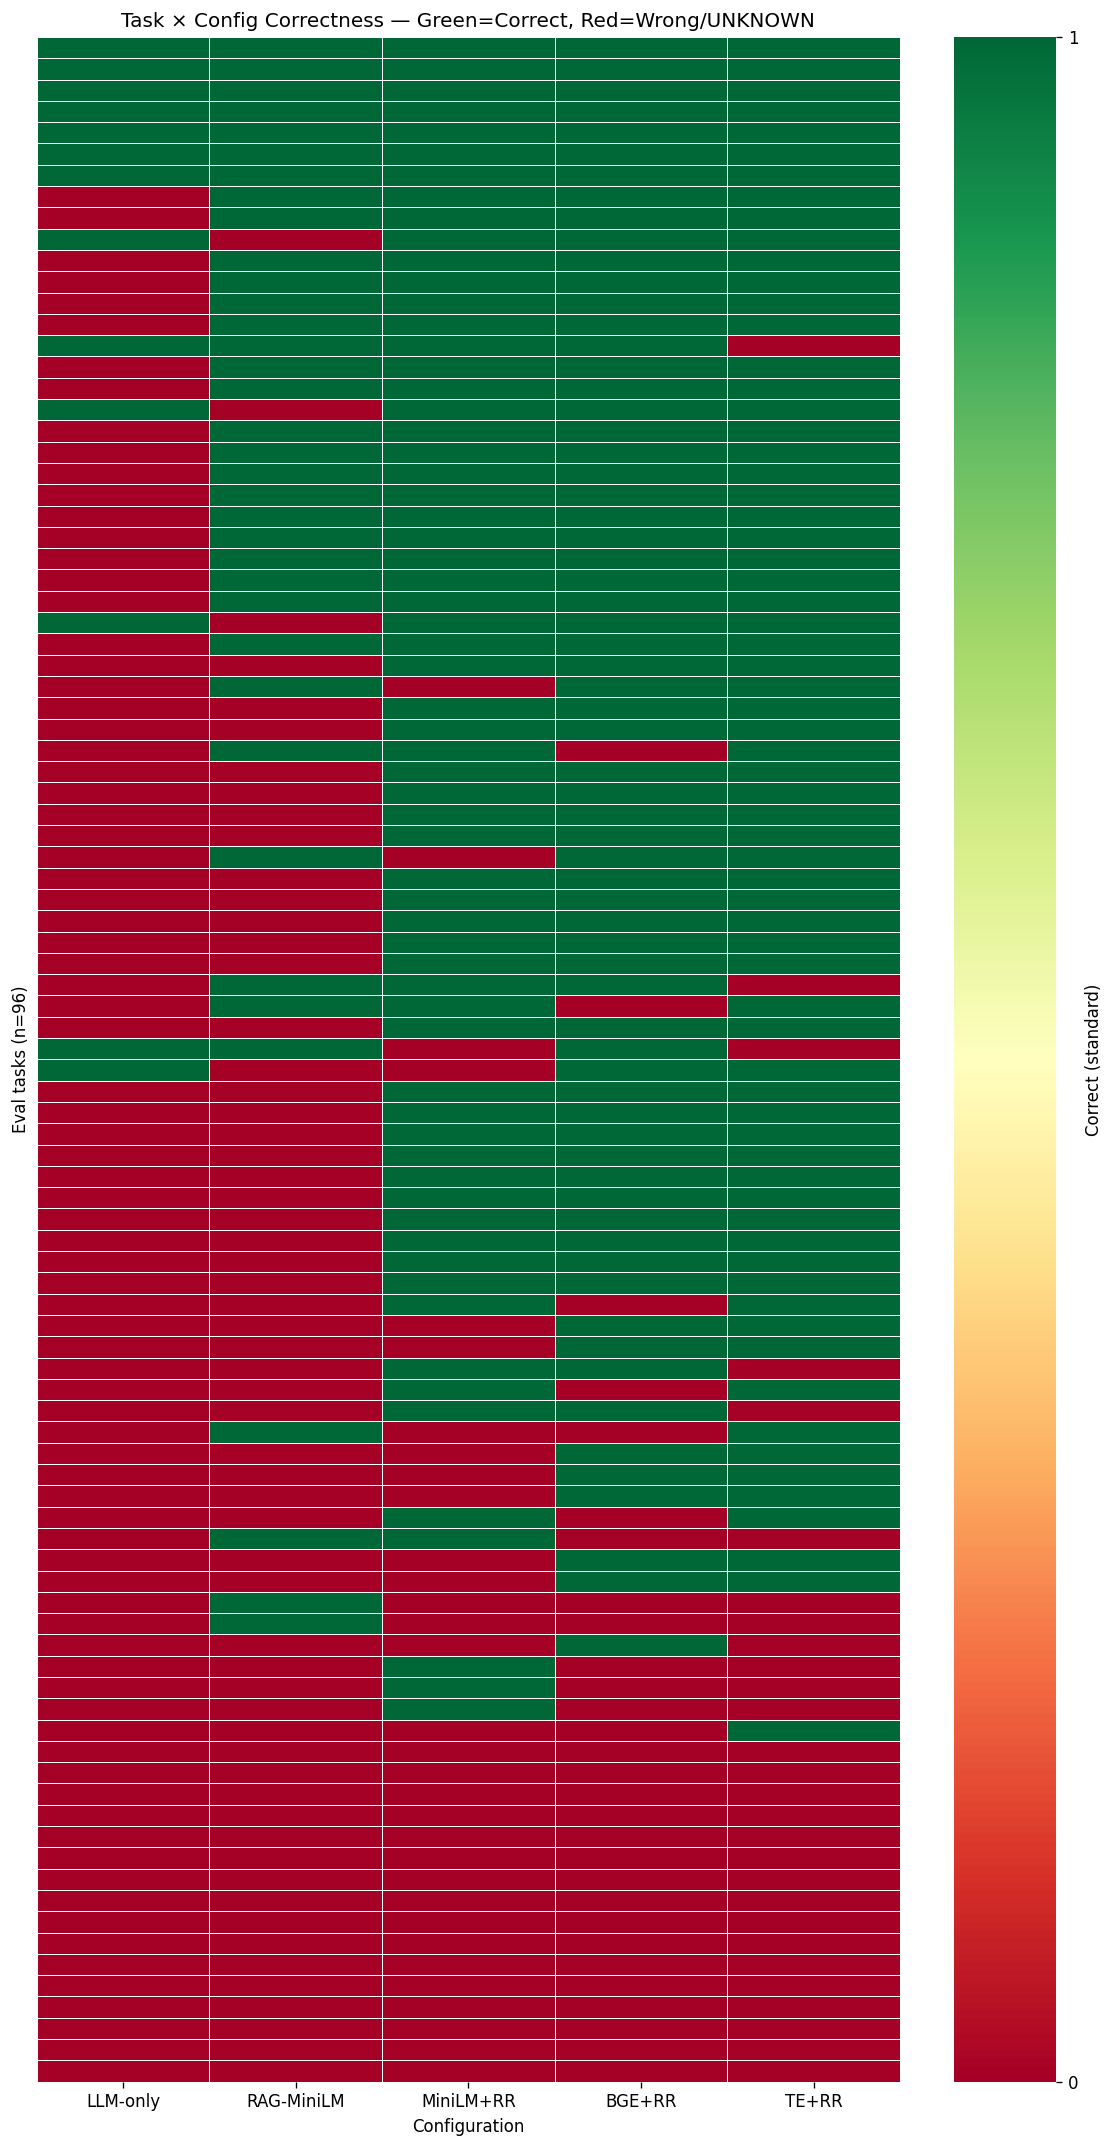

✓ fig10_task_correctness.png


In [15]:
# Build binary correctness matrix: rows = tasks, cols = configs
correctness = pd.DataFrame(index=range(len(master)), columns=short_labels)
for col, label in zip(available, short_labels):
    correctness[label] = master[f'{col}_std'].astype(int).values

# Sort by total correct count for readability
correctness['total'] = correctness[short_labels].sum(axis=1)
correctness = correctness.sort_values('total', ascending=False).drop('total', axis=1)

fig, ax = plt.subplots(figsize=(len(available)*1.5+2, min(len(master)*0.22+2, 18)))
sns.heatmap(correctness.astype(int), cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.3, linecolor='white', ax=ax,
            cbar_kws={'label':'Correct (standard)', 'ticks':[0,1]},
            yticklabels=False)
ax.set_title('Task × Config Correctness — Green=Correct, Red=Wrong/UNKNOWN', fontsize=12)
ax.set_xlabel('Configuration')
ax.set_ylabel(f'Eval tasks (n={len(master)})')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig10_task_correctness.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig10_task_correctness.png')

## Figure 11 — Numeric Attributes: The Strongest Case for Retrieval

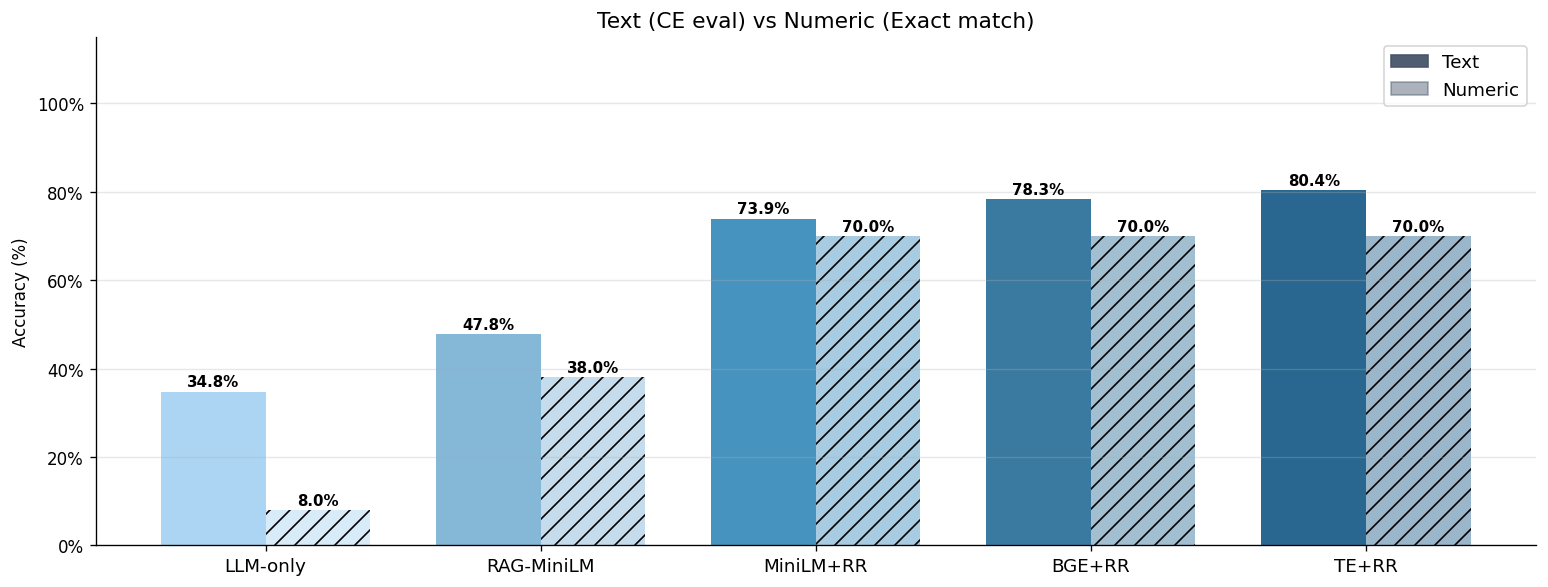

✓ fig11_numeric_strongest.png


In [19]:
COLORS = ['#A7D3F2', '#7FB3D5', '#3C8DBC', "#2F739B", '#1D5F8A', '#0B3C5D']

num_vals  = [master[master['attribute'].isin(num_attrs)][f'{c}_std'].mean()*100
             for c in available]
text_vals = [master[master['attribute'].isin(text_attrs)][f'{c}_ce'].isin(['correct','acceptable']).mean()*100
             for c in available]

labels = [CONFIG_LABELS[c] for c in available]
x = np.arange(len(available)); w = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x-w/2, text_vals, w, color=COLORS[:len(available)], alpha=0.95, label='Text attributes (CE eval)')
b2 = ax.bar(x+w/2, num_vals,  w, color=COLORS[:len(available)], alpha=0.45, label='Numeric attributes (exact match)', hatch='//')

for bar in list(b1)+list(b2):
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Text (CE eval) vs Numeric (Exact match)', fontsize=13)
ax.grid(axis='y', alpha=0.3)

import matplotlib.patches as mpatches
text_patch    = mpatches.Patch(color='#475569', alpha=0.95, label='Text')
numeric_patch = mpatches.Patch(color='#475569', alpha=0.45, label='Numeric')
ax.legend(handles=[text_patch, numeric_patch], fontsize=11)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig11_numeric_strongest.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig11_numeric_strongest.png')

## Figure 12 — Progressive Improvement: Each Step Adds Value

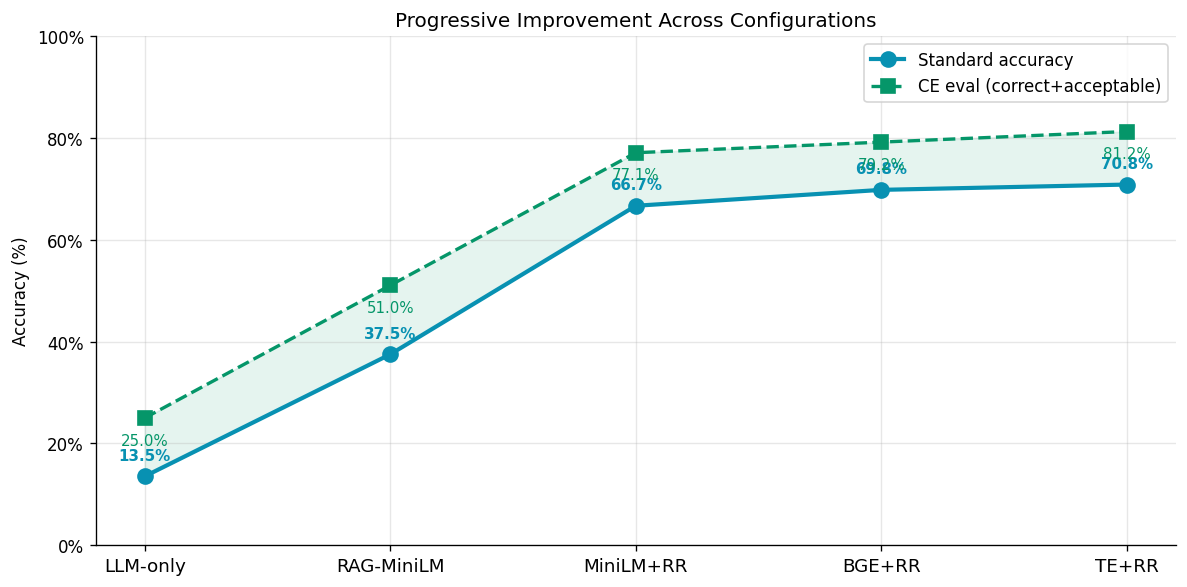

✓ fig12_progressive.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(sum_df))
ax.plot(x, sum_df['std'], 'o-', color='#0891B2', linewidth=2.5,
        markersize=9, label='Standard accuracy', zorder=3)
ax.plot(x, sum_df['ce'],  's--', color='#059669', linewidth=2,
        markersize=8, label='CE eval (correct+acceptable)', zorder=3)
ax.fill_between(x, sum_df['std'], sum_df['ce'], alpha=0.1, color='#059669')

for i, (s, c) in enumerate(zip(sum_df['std'], sum_df['ce'])):
    ax.annotate(f'{s:.1f}%', (i, s), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9, fontweight='bold', color='#0891B2')
    ax.annotate(f'{c:.1f}%', (i, c), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=9, color='#059669')

ax.set_xticks(x); ax.set_xticklabels(sum_df['config'], fontsize=11)
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Progressive Improvement Across Configurations')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig12_progressive.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig12_progressive.png')

## 5. Error Analysis — Task Level

In [17]:
task_rows = []
for _, row in master.iterrows():
    outcomes  = {col: row[f'{col}_outcome'] for col in available if f'{col}_outcome' in master.columns}
    n_correct = sum(1 for v in outcomes.values() if v in {'correct','correct (CE)'})
    task_rows.append({
        'df1_idx':      row['df1_idx'],
        'attribute':    row['attribute'],
        'ground_truth': row['ground_truth'],
        **{col: row[col] for col in available if col in master.columns},
        **outcomes,
        'n_correct':  n_correct,
        'n_configs':  len(available)
    })
task_df = pd.DataFrame(task_rows)
task_df.to_csv(ERROR_ANALYSIS_FILE, index=False)
print(f'✓ Saved to {ERROR_ANALYSIS_FILE}')

failures = task_df[task_df['n_correct'] == 0]
easy     = task_df[task_df['n_correct'] == len(available)]
print(f'\nPersistent failures (0/{len(available)} correct): {len(failures)}')
print(f'Easy wins (all {len(available)} correct):          {len(easy)}')
print(f'Tasks with at least one failure:                   {len(task_df) - len(easy)}')

✓ Saved to results_ohne_UNKNOWN/error_analysis.csv

Persistent failures (0/5 correct): 7
Easy wins (all 5 correct):          16
Tasks with at least one failure:                   80


## 6. Persistent Failures

In [18]:
print(f'=== PERSISTENT FAILURES (0/{len(available)} configs correct) ===\n')
failures[['df1_idx','attribute','ground_truth'] + available]

=== PERSISTENT FAILURES (0/5 configs correct) ===



,df1_idx,attribute,ground_truth,llm_prediction,rag_minilm_prediction,rag_minilm_reranker_prediction,rag_bge_reranker_prediction,rag_te_reranker_prediction
16,12,model_number,90YV0DQ0-M0NA00,wrong value,wrong value,wrong value,wrong value,wrong value
48,43,width_mm,80.5,UNKNOWN,wrong value,UNKNOWN,wrong value,wrong value
70,86,height_mm,67.0,UNKNOWN,wrong value,wrong value,wrong value,wrong value
71,86,width_mm,15.0,UNKNOWN,UNKNOWN,wrong value,wrong value,wrong value
75,95,model,ISS,wrong value,wrong value,wrong value,wrong value,UNKNOWN
82,137,model,L200,wrong value,wrong value,wrong value,wrong value,wrong value
92,188,model,Barracuda 7200.12,wrong value,wrong value,wrong value,wrong value,wrong value


## 7. Easy Wins

In [19]:
print(f'=== EASY WINS (all {len(available)} configs correct) ===\n')
easy[['df1_idx','attribute','ground_truth']]

=== EASY WINS (all 5 configs correct) ===



,df1_idx,attribute,ground_truth
1,2,model_number,CSSD-F960GBMP510
6,5,bus_type,PCIe 3.0 x16
8,6,bus_type,USB 3.0
10,9,bus_type,PCIe 3.0 x16
14,11,bus_type,PCIe 3.0
18,14,model_number,GV-R56XTGAMING OC-6GD
19,15,bus_type,PCIe 3.0 x16
24,18,read_speed_mb_s,550.0
25,18,write_speed_mb_s,520.0
26,19,bus_type,PCIe 3.0 x16


## 8. Detailed Attribute-Level View

In [20]:
for attr in sorted(master['attribute'].unique()):
    sub = task_df[(task_df['attribute'] == attr) & (task_df['n_correct'] < len(available))]
    if len(sub) == 0: continue
    print(f'\n{"="*80}\nATTRIBUTE: {attr}\n{"="*80}')
    for _, row in sub.iterrows():
        print(f'\n  Row {int(row["df1_idx"])} | GT: {row["ground_truth"]}')
        for col in available:
            pred = row.get(col,'—')
            out  = row.get(f'{col}_outcome','—')
            sym  = '✓' if out in {'correct','correct (CE)'} else '✗'
            print(f'    {sym} {CONFIG_LABELS[col]:<25} → {str(pred):<35} [{out}]')


ATTRIBUTE: bus_type

  Row 12 | GT: PCIe 4.0
    ✗ LLM-only                  → correct (CE)                        [—]
    ✗ RAG-MiniLM                → wrong value                         [—]
    ✗ MiniLM+RR                 → correct                             [—]
    ✗ BGE+RR                    → correct                             [—]
    ✗ TE+RR                     → correct                             [—]

  Row 25 | GT: PCIe 3.0
    ✗ LLM-only                  → correct (CE)                        [—]
    ✗ RAG-MiniLM                → correct                             [—]
    ✗ MiniLM+RR                 → UNKNOWN                             [—]
    ✗ BGE+RR                    → correct (CE)                        [—]
    ✗ TE+RR                     → correct (CE)                        [—]

  Row 26 | GT: SATA III
    ✗ LLM-only                  → wrong value                         [—]
    ✗ RAG-MiniLM                → wrong value                         [—]
    ✗ MiniLM+RR 

## 9. All Figures Summary

In [21]:
print('='*60)
print('ALL FIGURES SAVED')
print('='*60)
for f in sorted(os.listdir(FIGURES_DIR)):
    size = os.path.getsize(f'{FIGURES_DIR}/{f}') / 1024
    print(f'  {f:<45} {size:.0f} KB')
print(f'\nCSV files:')
print(f'  {MASTER_FILE}')
print(f'  {ERROR_ANALYSIS_FILE}')

ALL FIGURES SAVED
  fig10_task_correctness.png                    63 KB
  fig11_numeric_strongest.png                   56 KB
  fig12_progressive.png                         89 KB
  fig1_overall_accuracy.png                     76 KB
  fig2_heatmap_standard.png                     106 KB
  fig3_heatmap_ce.png                           103 KB
  fig4_outcome_stacked.png                      62 KB
  fig5_numeric_vs_text.png                      63 KB
  fig6_improvement.png                          50 KB
  fig7_std_vs_ce.png                            66 KB
  fig8_unknown_rate.png                         49 KB
  fig9_per_config_bars.png                      87 KB

CSV files:
  results_ohne_UNKNOWN/master_predictions.csv
  results_ohne_UNKNOWN/error_analysis.csv


# Retrieval Metrics

In [5]:
import torch
import numpy as np
import pandas as pd
import math
import glob
from sentence_transformers import util

# ── Load ──────────────────────────────────────────────────────────────────────
DATA_DIR       = 'normalized_products'
EMBEDDINGS_DIR = 'embeddings'

df1    = pd.read_json(f'{DATA_DIR}/dataset_1_normalized.json')
df2    = pd.read_json(f'{DATA_DIR}/dataset_2_normalized.json')
df3    = pd.read_json(f'{DATA_DIR}/dataset_3_normalized.json')
df4    = pd.read_json(f'{DATA_DIR}/dataset_4_normalized.json')
kb     = pd.concat([df2,df3,df4], ignore_index=True)

eval_df       = pd.read_csv('eval_set.csv')
query_indices = pd.read_csv('query_indices.csv').iloc[:,0].tolist()
query_df      = df1.loc[query_indices].copy()
query_idx_to_pos = {idx: pos for pos, idx in enumerate(query_df.index)}

# Load embeddings
print('Loading embeddings...')
# embeddings = {
#     'MiniLM':  (torch.load(f'{EMBEDDINGS_DIR}/minilm_kb.pt'),
#                 torch.load(f'{EMBEDDINGS_DIR}/minilm_query.pt')),
#     'BGE':     (torch.load(f'{EMBEDDINGS_DIR}/bge_kb.pt'),
#                 torch.load(f'{EMBEDDINGS_DIR}/bge_query.pt')),
#     'OpenAI':  (torch.load(f'{EMBEDDINGS_DIR}/openai_kb.pt'),
#                 torch.load(f'{EMBEDDINGS_DIR}/openai_query.pt')),
# }

embeddings = {
    'MiniLM': (torch.load(f'{EMBEDDINGS_DIR}/minilm_kb.pt',  map_location='cpu'),
               torch.load(f'{EMBEDDINGS_DIR}/minilm_query.pt', map_location='cpu')),
    'BGE':    (torch.load(f'{EMBEDDINGS_DIR}/bge_kb.pt',     map_location='cpu'),
               torch.load(f'{EMBEDDINGS_DIR}/bge_query.pt',  map_location='cpu')),
    'OpenAI': (torch.load(f'{EMBEDDINGS_DIR}/openai_kb.pt',  map_location='cpu'),
               torch.load(f'{EMBEDDINGS_DIR}/openai_query.pt', map_location='cpu')),
}

print('Done.')

# ── Metrics function ──────────────────────────────────────────────────────────
def retrieval_metrics(kb_embs, query_embs, k):
    recall_sum = precision_sum = ndcg_sum = f1_sum = 0.0

    for _, task in eval_df.iterrows():
        idx        = task['df1_idx']
        cluster_id = query_df.loc[idx, 'cluster_id']
        q_emb      = query_embs[query_idx_to_pos[idx]]
        scores     = util.cos_sim(q_emb, kb_embs)[0]
        top_idx    = np.argsort(-scores.cpu().numpy())[:k]
        retrieved  = kb.iloc[top_idx]
        matches    = (retrieved['cluster_id'] == cluster_id).values

        # Recall@K
        recall = int(matches.any())
        recall_sum += recall

        # Precision@K
        prec = matches.sum() / k
        precision_sum += prec

        # NDCG@K
        dcg  = sum(1.0/math.log2(r+2) for r,m in enumerate(matches) if m)
        idcg = sum(1.0/math.log2(r+2) for r in range(min(int(matches.sum()),k)))
        ndcg_sum += (dcg/idcg) if idcg > 0 else 0.0

        # F1@K
        f1 = (2*prec*recall/(prec+recall)) if (prec+recall) > 0 else 0.0
        f1_sum += f1

    n = len(eval_df)
    return {
        'recall':    recall_sum    / n,
        'precision': precision_sum / n,
        'ndcg':      ndcg_sum      / n,
        'f1':        f1_sum        / n,
    }

# ── Run for all models and K values ──────────────────────────────────────────
K_VALUES = [3, 5, 10, 20]

print(f'\n{"Model":<12} {"K":>4} {"Recall":>8} {"Precision":>10} {"NDCG":>8} {"F1":>8}')
print('-' * 55)

all_results = []
for model_name, (kb_embs, q_embs) in embeddings.items():
    for k in K_VALUES:
        m = retrieval_metrics(kb_embs, q_embs, k)
        print(f'{model_name:<12} {k:>4} {m["recall"]:>8.3f} {m["precision"]:>10.3f} '
              f'{m["ndcg"]:>8.3f} {m["f1"]:>8.3f}')
        all_results.append({'model': model_name, 'k': k, **m})

results_df = pd.DataFrame(all_results)
results_df.to_csv('results_mit_UNKNOWN/retrieval_metrics.csv', index=False)
print('\n✓ Saved to results_mit_UNKNOWN/retrieval_metrics.csv')

Loading embeddings...
Done.

Model           K   Recall  Precision     NDCG       F1
-------------------------------------------------------
MiniLM          3    0.479      0.215    0.395    0.286
MiniLM          5    0.708      0.196    0.480    0.297
MiniLM         10    0.865      0.171    0.523    0.279
MiniLM         20    0.938      0.101    0.537    0.180
BGE             3    0.729      0.365    0.586    0.468
BGE             5    0.833      0.287    0.632    0.412
BGE            10    0.938      0.201    0.638    0.325
BGE            20    0.990      0.115    0.646    0.204
OpenAI          3    0.771      0.441    0.701    0.537
OpenAI          5    0.833      0.327    0.710    0.456
OpenAI         10    0.979      0.229    0.736    0.366
OpenAI         20    1.000      0.129    0.728    0.227

✓ Saved to results_mit_UNKNOWN/retrieval_metrics.csv


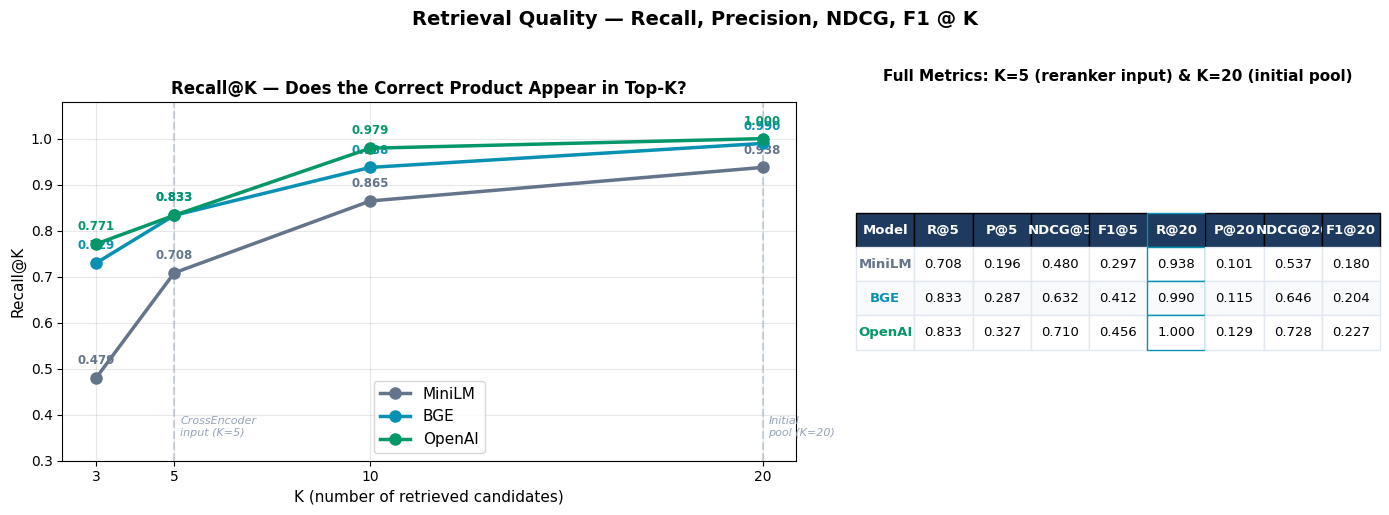

✓ fig_retrieval_metrics.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import numpy as np

metrics_df = pd.read_csv('results_mit_UNKNOWN/retrieval_metrics.csv')

COLORS = {'MiniLM': '#64748B', 'BGE': '#0891B2', 'OpenAI': '#059669'}
K_VALS = [3, 5, 10, 20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={'width_ratios': [1.4, 1]})

# ── Left: Recall@K line chart ─────────────────────────────────────────────────
ax = axes[0]
for model, color in COLORS.items():
    sub = metrics_df[metrics_df['model'] == model].sort_values('k')
    ax.plot(sub['k'], sub['recall'], 'o-', color=color, lw=2.5,
            markersize=8, label=model, zorder=3)
    # annotate each point
    for _, row in sub.iterrows():
        ax.annotate(f'{row["recall"]:.3f}',
                    (row['k'], row['recall']),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8.5, color=color, fontweight='bold')

# Mark K=5 and K=20 as pipeline reference points
for kv, label in [(5, 'CrossEncoder\ninput (K=5)'), (20, 'Initial\npool (K=20)')]:
    ax.axvline(kv, color='#CBD5E1', lw=1.5, linestyle='--', zorder=1)
    ax.text(kv+0.15, 0.35, label, fontsize=8, color='#94A3B8',
            style='italic', va='bottom')

ax.set_xticks(K_VALS)
ax.set_xlabel('K (number of retrieved candidates)', fontsize=11)
ax.set_ylabel('Recall@K', fontsize=11)
ax.set_ylim(0.3, 1.08)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{x:.1f}'))
ax.set_title('Recall@K — Does the Correct Product Appear in Top-K?',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)

# ── Right: Summary table K=5 and K=20 ────────────────────────────────────────
ax = axes[1]
ax.axis('off')

k5  = metrics_df[metrics_df['k']==5].set_index('model')
k20 = metrics_df[metrics_df['k']==20].set_index('model')

col_labels = ['Model',
              'R@5','P@5','NDCG@5','F1@5',
              'R@20','P@20','NDCG@20','F1@20']
table_data = []
for model in ['MiniLM','BGE','OpenAI']:
    row = [model,
           f'{k5.loc[model,"recall"]:.3f}',
           f'{k5.loc[model,"precision"]:.3f}',
           f'{k5.loc[model,"ndcg"]:.3f}',
           f'{k5.loc[model,"f1"]:.3f}',
           f'{k20.loc[model,"recall"]:.3f}',
           f'{k20.loc[model,"precision"]:.3f}',
           f'{k20.loc[model,"ndcg"]:.3f}',
           f'{k20.loc[model,"f1"]:.3f}',
    ]
    table_data.append(row)

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1, 2.2)

# Style header
for c in range(len(col_labels)):
    tbl[(0,c)].set_facecolor('#1E3A5F')
    tbl[(0,c)].set_text_props(color='white', fontweight='bold')

# Style model column and alternate rows
for r in range(1, 4):
    model = table_data[r-1][0]
    tbl[(r,0)].set_text_props(color=COLORS[model], fontweight='bold')
    for c in range(len(col_labels)):
        if r % 2 == 0:
            tbl[(r,c)].set_facecolor('#F8FAFC')
        tbl[(r,c)].set_edgecolor('#E2E8F0')

# Separator between K=5 and K=20 groups
for r in range(4):
    tbl[(r,5)].set_edgecolor('#0891B2')

ax.set_title('Full Metrics: K=5 (reranker input) & K=20 (initial pool)',
             fontsize=11, fontweight='bold', pad=15)

plt.suptitle('Retrieval Quality — Recall, Precision, NDCG, F1 @ K',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'figures_final/fig_retrieval_metrics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_retrieval_metrics.png')

NameError: name 'FIGURES_DIR' is not defined

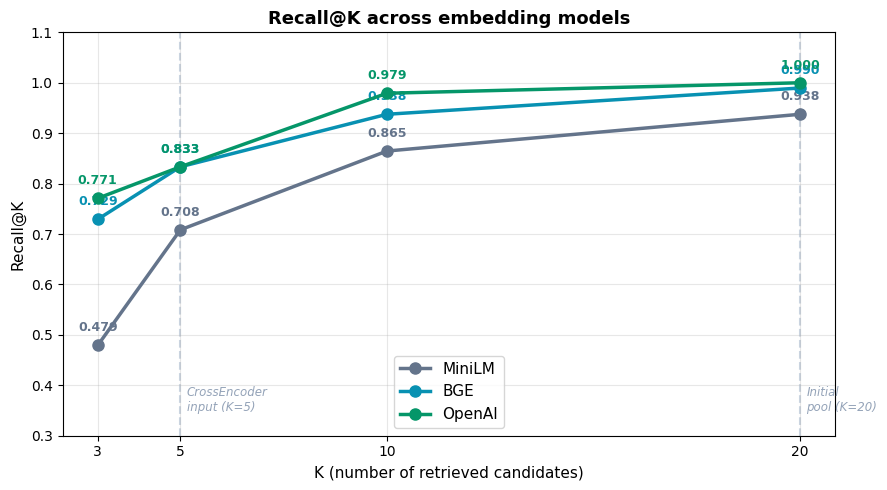

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for model, color in COLORS.items():
    sub = metrics_df[metrics_df['model']==model].sort_values('k')
    ax.plot(sub['k'], sub['recall'], 'o-', color=color, lw=2.5,
            markersize=8, label=model, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(f'{row["recall"]:.3f}', (row['k'], row['recall']),
                    textcoords='offset points', xytext=(0,10),
                    ha='center', fontsize=9, color=color, fontweight='bold')

ax.axvline(5,  color='#CBD5E1', lw=1.5, linestyle='--', zorder=1)
ax.axvline(20, color='#CBD5E1', lw=1.5, linestyle='--', zorder=1)
ax.text(5.15,  0.35, 'CrossEncoder\ninput (K=5)',  fontsize=8.5, color='#94A3B8', style='italic')
ax.text(20.15, 0.35, 'Initial\npool (K=20)',       fontsize=8.5, color='#94A3B8', style='italic')

ax.set_xticks(K_VALS)
ax.set_xlabel('K (number of retrieved candidates)', fontsize=11)
ax.set_ylabel('Recall@K', fontsize=11)
ax.set_ylim(0.3, 1.1)
ax.set_title('Recall@K across embedding models',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_recall_main.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_recall_main.png')